In [1]:
# imports for reproducibility and baseline setup
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Baseline notebook ready")


Baseline notebook ready


In [3]:
# Generating a synthetic dataset for demonstration
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=SEED
)

X = pd.DataFrame(X)
y = pd.Series(y, name="label")

print(X.shape, y.shape)


(5000, 20) (5000,)


In [4]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (3500, 20)
Test size: (1500, 20)


### Baseline Model (Synthetic Data)

This experiment validates the end-to-end machine learning pipeline using a synthetic
binary classification dataset. The objective is not to achieve high accuracy, but to
verify correctness of data handling, training, inference, and evaluation prior to
introducing real IoT network traffic data.


In [5]:
# Training a Random Forest Classifier as a baseline model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.95      0.94       750
           1       0.95      0.92      0.94       750

    accuracy                           0.94      1500
   macro avg       0.94      0.94      0.94      1500
weighted avg       0.94      0.94      0.94      1500



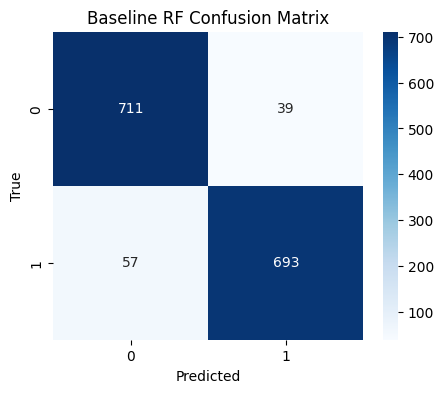

In [6]:
# Displaying the confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Baseline RF Confusion Matrix")

# Saving the confusion matrix figure
plt.savefig("../results/baseline_rf_confusion_matrix.png", bbox_inches="tight")
plt.show()
plt.close()